### langgraph(Graph API)

compnents of langgraph
- edges
- Nodes
- state

In [1]:
from typing import Annotated 
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]


graph = StateGraph(State)


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(model = "qwen/qwen3.6-27b")

In [5]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.17'}}, client=<groq.resources.chat.completions.Completions object at 0x0000029277CC4EC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000029277CC5940>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder = StateGraph(State)

graph_builder.add_node("llmchatbot",chatbot)
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph = graph_builder.compile()

In [8]:
response =graph.invoke({"messages": "Hi"})

In [9]:
response["messages"][-1].content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hi". This is a standard greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or request is made.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting politely\n   - Offer assistance\n   - Keep it open-ended to encourage the user to share what they need\n4.  **Draft Response (Mental):** "Hello! How can I assist you today?" \n5.  **Refine Response:** Keep it friendly, concise, and ready for follow-up. Matches standard AI assistant behavior.\n6.  **Final Output Generation:** "Hello! How can I help you today?" (or similar)✅\n</think>\n\nHello! How can I help you today?'

In [10]:
import re

for event in graph.stream({"messages": "Hi,How are you?"}):
    for values in event.values():
        content = values["messages"][-1].content

        # Remove the <think>...</think> block if it exists
        clean_content = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL).strip()

        # Only print if there is remaining text to display
        if clean_content:
            print(clean_content)

Hi! I'm doing well, thank you for asking. I'm here and ready to help you with whatever you need. How are you doing today? What can I assist you with? 😊


In [11]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=3, api_key=os.environ.get("TAVILY_API_KEY"))
tool.invoke("what happened in bangalore today?")

{'query': 'what happened in bangalore today?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.youtube.com/watch?v=CFNLayoxdsk',
   'title': 'Bengaluru Wall Collapse Tragedy: 8 Dead at Bowring Hospital Amid Heavy Rain, Rescue On | News9',
   'content': 'today a very tragic incident has happened in Bengaluru due to the heavy rains and uh lot of high flow winds. And it has rained a lot. Here in this place, uh I think uh due to the fall of the wall, about uh yeah, seven people have died. And the latest reports what I have is that one more death has happened near the Vega Mall. That is the what the latest information what I got right now. So, the total death has been eight today. Seven here, one is in the south of Bengaluru. Now, I think in this [...] Met Department issuing a yellow alert for continued rainfall, thunderstorms, and gusty winds. Several parts of Bengaluru reported waterlogging, fallen trees, and major traffic disruptions, raisi

In [12]:
def multiply(a: int, b: int) -> int:
    """
    Multiplies two integers and returns the result.
    args:
        a (int): The first integer.
        b (int): The second integer.
    Returns:
        int: The product of the two integers.
    """
    return a * b

In [13]:
tools= [tool,multiply]

In [14]:
llm_with_tool=llm.bind_tools(tools)

In [15]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.17'}}, client=<groq.resources.chat.completions.Completions object at 0x0000029277CC4EC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000029277CC5940>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'str

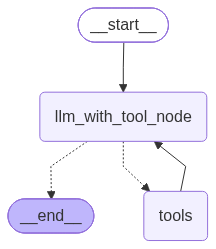

In [20]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver


memory = MemorySaver()

##node definition
def llm_with_tool_node(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("llm_with_tool_node",llm_with_tool_node)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"llm_with_tool_node")
builder.add_conditional_edges("llm_with_tool_node",tools_condition)
##builder.add_edge("tools",END)
builder.add_edge("tools","llm_with_tool_node")
builder.add_edge("llm_with_tool_node",END)

graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display, HTML
display(Image(graph.get_graph().draw_mermaid_png()))


In [21]:
config = {"configurable":{"thread_id": "thread_1"}}
response = graph.invoke({"messages": "Hi my name is John"}, config=config)
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi my name is John
================================== Ai Message ==================================

Hello John! It's nice to meet you. How can I help you today?


In [22]:

response = graph.invoke({"messages": "Hi, what is my name?"}, config=config)
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Hi my name is John
================================== Ai Message ==================================

Hello John! It's nice to meet you. How can I help you today?
================================ Human Message =================================

Hi, what is my name?
================================== Ai Message ==================================

Your name is John! How can I help you today?


### Streaming

In [23]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [24]:
def superbot(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

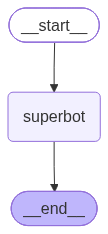

In [25]:
graph = StateGraph(State)

graph.add_node("superbot",superbot)

graph.add_edge(START,"superbot")
graph.add_edge("superbot",END)


graph_builder = graph.compile(checkpointer=memory)

from IPython.display import Image, display, HTML
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [26]:
config = {"configurable":{"thread_id": "thread_2"}}
graph_builder.invoke({"messages": "Hi my name is John,i like cricket"}, config=config)

{'messages': [HumanMessage(content='Hi my name is John,i like cricket', additional_kwargs={}, response_metadata={}, id='5341a5e3-21f3-47ef-9e75-07c2442c6d3b'),
  AIMessage(content="Hello John! It's nice to meet you. That's great that you like cricket; it's a fantastic sport. Do you have a favorite team or player you follow?", additional_kwargs={'reasoning_content': 'The user is introducing themselves as John and stating they like cricket.\nThere are no questions asked, and no specific tasks requested that would require the use of the provided tools (search or multiplication).\nThe appropriate response is a friendly acknowledgement of the introduction and the interest in cricket.\n\nPlan:\n1. Greet John.\n2. Acknowledge his interest in cricket.\n3. Ask a follow-up question to keep the conversation going (e.g., favorite team, player, or format).\n\nNo tool calls are needed.\n'}, response_metadata={'token_usage': {'completion_tokens': 147, 'prompt_tokens': 1938, 'total_tokens': 2085, 'com

Stream() Astream()

mode = updates , mode = values

In [27]:
for chunk in graph_builder.stream({"messages": " I also like football"}, config=config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content="That's awesome, John! It's great to have a couple of sports to follow. When you say football, do you mean soccer or American football? And do you have a favorite team or player you cheer for?", additional_kwargs={'reasoning_content': 'Here\'s a thinking process:\n\n1.  **Analyze User Input:** The user says "I also like football".\n2.  **Identify Key Information:** User likes both cricket and football. Name is John.\n3.  **Determine Intent:** The user is sharing personal interests/hobbies. This is a conversational turn.\n4.  **Formulate Response:**\n   - Acknowledge the new information (likes football too)\n   - Keep the conversation engaging and friendly\n   - Ask a follow-up question to continue the dialogue (e.g., favorite team, position, which type of football - soccer/American football, etc.)\n   - Maintain a natural, conversational tone.\n5.  **Draft Response:** "That\'s awesome, John! Football is another great sport to follow. Do you 

In [28]:
for chunk in graph_builder.stream({"messages": " I also like kabadi"}, config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi my name is John,i like cricket', additional_kwargs={}, response_metadata={}, id='5341a5e3-21f3-47ef-9e75-07c2442c6d3b'), AIMessage(content="Hello John! It's nice to meet you. That's great that you like cricket; it's a fantastic sport. Do you have a favorite team or player you follow?", additional_kwargs={'reasoning_content': 'The user is introducing themselves as John and stating they like cricket.\nThere are no questions asked, and no specific tasks requested that would require the use of the provided tools (search or multiplication).\nThe appropriate response is a friendly acknowledgement of the introduction and the interest in cricket.\n\nPlan:\n1. Greet John.\n2. Acknowledge his interest in cricket.\n3. Ask a follow-up question to keep the conversation going (e.g., favorite team, player, or format).\n\nNo tool calls are needed.\n'}, response_metadata={'token_usage': {'completion_tokens': 147, 'prompt_tokens': 1938, 'total_tokens': 2085, 'compl

In [31]:
async for chunk in graph_builder.astream_events({"messages": [" I also like tennis"]}, config=config,stream_mode="values"):
    print(chunk)

{'event': 'on_chain_start', 'data': {'input': {'messages': [' I also like tennis']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a042ce-095d-7502-8005-00c00ed627e5', 'metadata': {'thread_id': 'thread_2', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '01a042ce-095d-7502-8005-00c00ed627e5', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': 'thread_2', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content='Hi my name is John,i like cricket', additional_kwargs={}, response_metadata={}, id='5341a5e3-21f3-47ef-9e75-07c2442c6d3b'), AIMessage(content="Hello John! It's nice to meet you. That's great that you like cricket; it's a fantastic sport. Do you have a favorite team or player you follow?", additional_kwargs={'reasoning_content': 'The user is introducing themselves as John and stating they like cricket.\nThere are no questions asked, and no specific tasks requested that would require the use of the provi